# Классификация YouTube-видео по жанру

**Цель:** предсказать категорию (жанр) короткого видеоклипа по его метаданным.

**Данные:** `data/youtube_data.csv` — 17 624 видео с YouTube.  
**Признаки:** техн. параметры (длительность, битрейт, разрешение, FPS, кодек), текст (заголовок, описание, хэштеги), вовлечённость (просмотры, лайки, комментарии).  
**Целевая переменная:** `category`.

---
## Содержание
1. Загрузка и первичный осмотр
2. Разведочный анализ (EDA)
3. Предобработка данных
4. Базовая модель (Logistic Regression + TF-IDF)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

---
## 1. Загрузка и первичный осмотр

In [2]:
df = pd.read_csv('data/youtube_data.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок')
df.head(3)

Размер датасета: 17589 строк, 17 колонок


,video_id,duration,bitrate,bitrate(video),height,width,frame rate,frame rate(est.),codec,category,url,title,description,hashtags,views,likes,comments
0,--F7dc-_FSI,180,5777,5640,1920,1080,25.00,25.00,h264,News & Politics,https://www.youtube.com/watch?v=--F7dc-_FSI,«السودان ينتفض» أمام السفارة بالقاهرة,حرية سلام وعدالة، الثورة خيار الشعب.. بهذا اله...,"في, عسكري, حكم, حرية, بخصوص, المصري اليوم, الس...",4078,41,3
1,--cCAD-8Y_U,930,1195,1001,1280,720,30.00,30.00,h264,Gaming,https://www.youtube.com/watch?v=--cCAD-8Y_U,Pokemon Tower Defense Episodio 2,Espero que tenham gostado do video!,"Pokémon (Anime/Manga Franchise), Pokémon (Vide...",33,2,1
2,--g2gG8pQ0w,233,3028,2833,1280,720,23.98,23.98,h264,Comedy,https://www.youtube.com/watch?v=--g2gG8pQ0w,New Hip Hop - Kemo Treats - Pancakes,Download all our music for FREE just enter $0....,"breaking bad spoof, Recipes, Pancakes, canada,...",13227,135,17


In [3]:
df.dtypes

video_id                str
duration              int64
bitrate               int64
bitrate(video)        int64
height                int64
width                 int64
frame rate          float64
frame rate(est.)    float64
codec                   str
category                str
url                     str
title                   str
description             str
hashtags                str
views                 int64
likes                 int64
comments              int64
dtype: object

In [4]:
# Пропущенные значения
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')

,missing,pct
description,1112,6.32
hashtags,1576,8.96


In [5]:
# Дубликаты по video_id
n_dup = df['video_id'].duplicated().sum()
print(f'Дубликатов по video_id: {n_dup}')

Дубликатов по video_id: 0


In [6]:
print('Уникальных категорий:', df['category'].nunique())
print(df['category'].value_counts())

Уникальных категорий: 16
category
People & Blogs          3946
Music                   2966
Entertainment           2252
Gaming                  1420
Sports                  1230
Comedy                  1176
Autos & Vehicles         798
Education                644
News & Politics          636
Travel & Events          590
Film & Animation         587
Pets & Animals           476
Howto & Style            340
Science & Technology     283
Nonprofits & Activis     227
Shows                     18
Name: count, dtype: int64


---
## 2. Разведочный анализ (EDA)

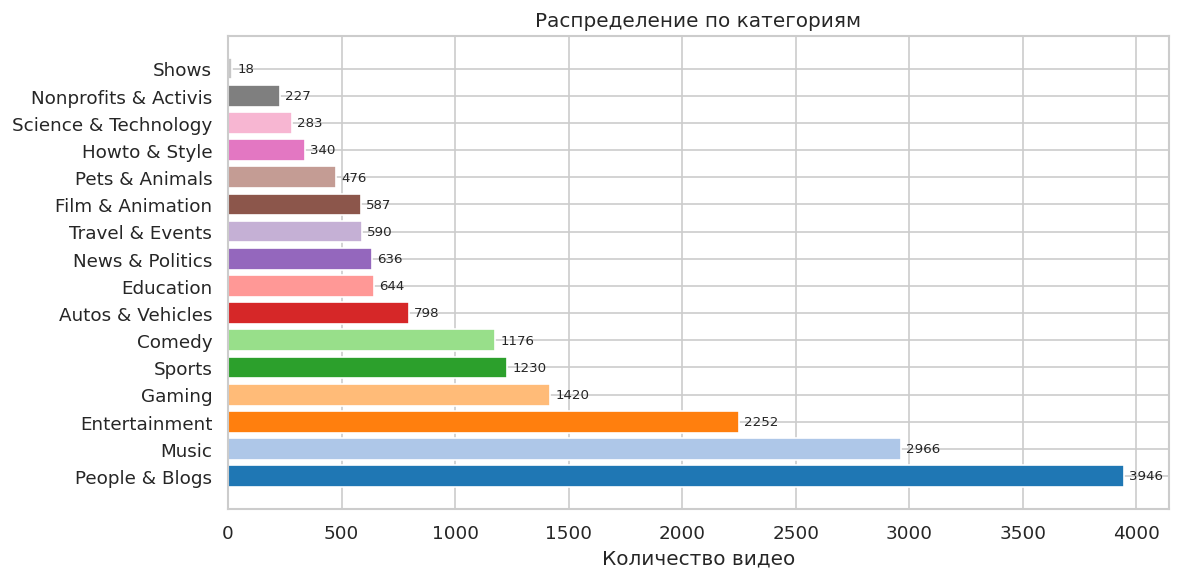

In [7]:
# Распределение категорий
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['category'].value_counts()
bars = ax.barh(counts.index, counts.values, color=sns.color_palette('tab20', len(counts)))
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel('Количество видео')
ax.set_title('Распределение по категориям')
plt.tight_layout()
plt.show()

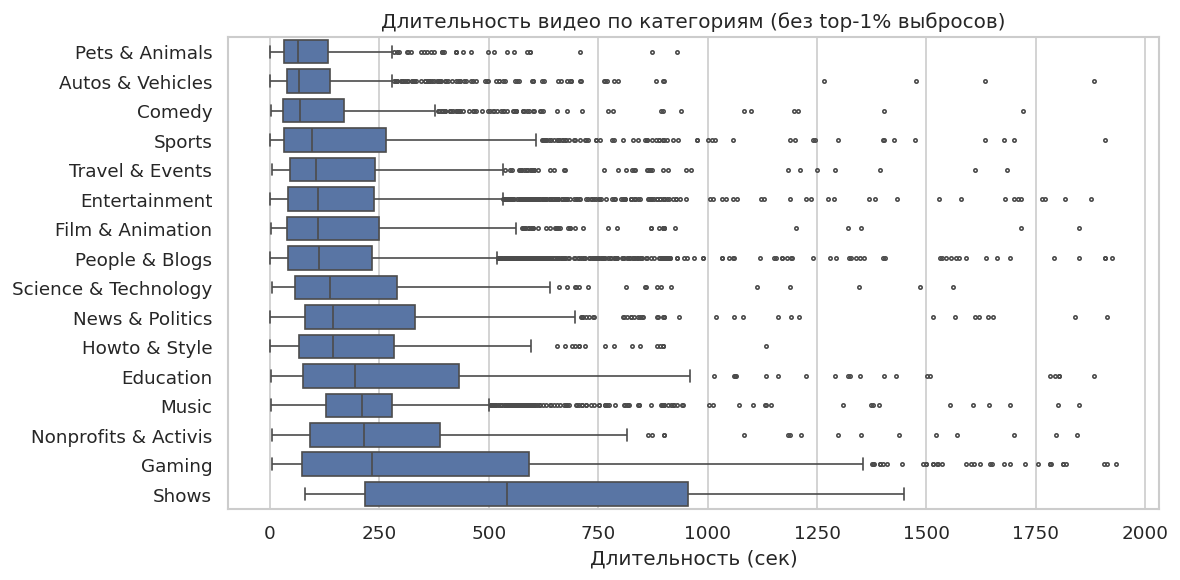

In [8]:
# Длительность видео по категориям (убираем выбросы > 99 перцентиля)
p99 = df['duration'].quantile(0.99)
df_trim = df[df['duration'] <= p99]

fig, ax = plt.subplots(figsize=(10, 5))
order = df_trim.groupby('category')['duration'].median().sort_values().index
sns.boxplot(data=df_trim, y='category', x='duration', order=order, ax=ax, fliersize=2)
ax.set_title('Длительность видео по категориям (без top-1% выбросов)')
ax.set_xlabel('Длительность (сек)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

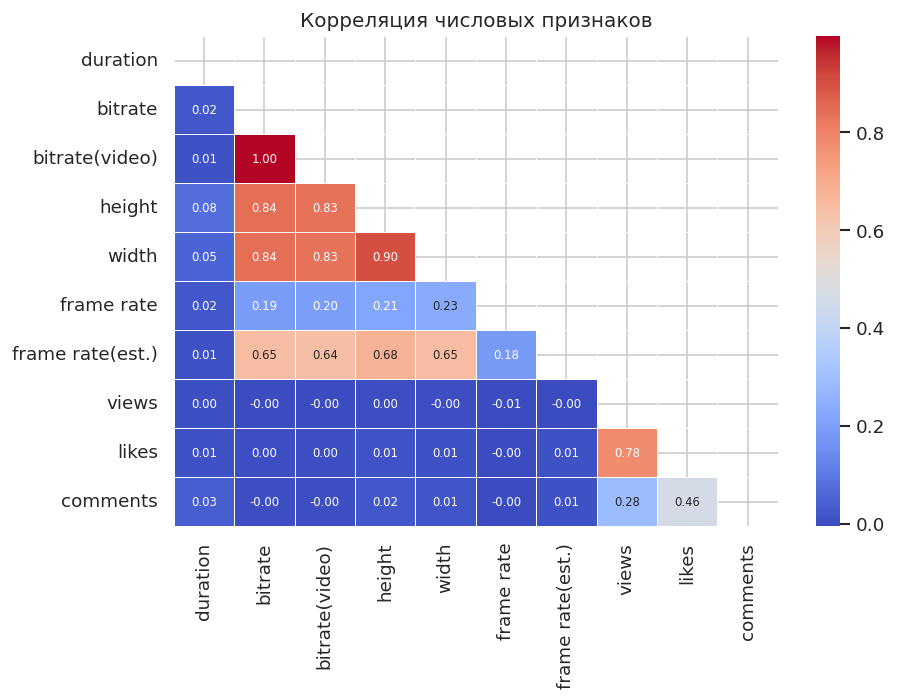

In [9]:
# Матрица корреляций числовых признаков
num_cols = ['duration', 'bitrate', 'bitrate(video)', 'height', 'width',
            'frame rate', 'frame rate(est.)', 'views', 'likes', 'comments']
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

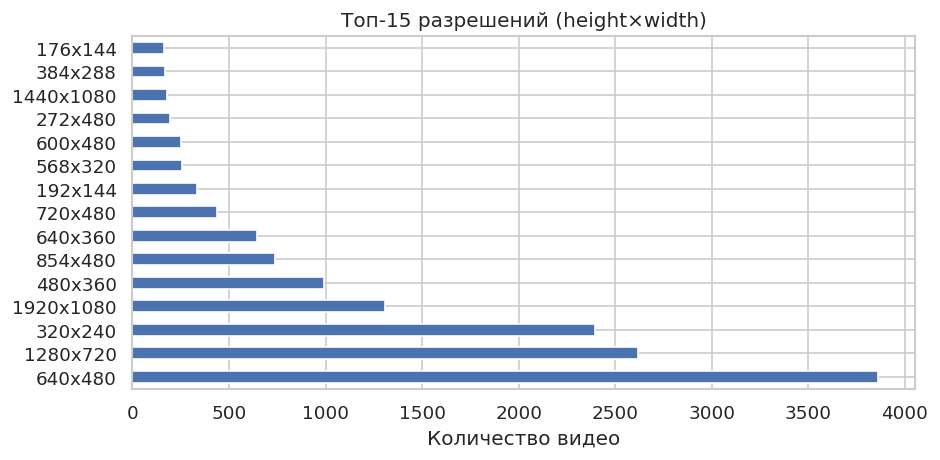

In [10]:
# Распределение разрешений (высота × ширина)
res_counts = (df['height'].astype(str) + 'x' + df['width'].astype(str)).value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 4))
res_counts.plot(kind='barh', ax=ax)
ax.set_xlabel('Количество видео')
ax.set_title('Топ-15 разрешений (height×width)')
plt.tight_layout()
plt.show()

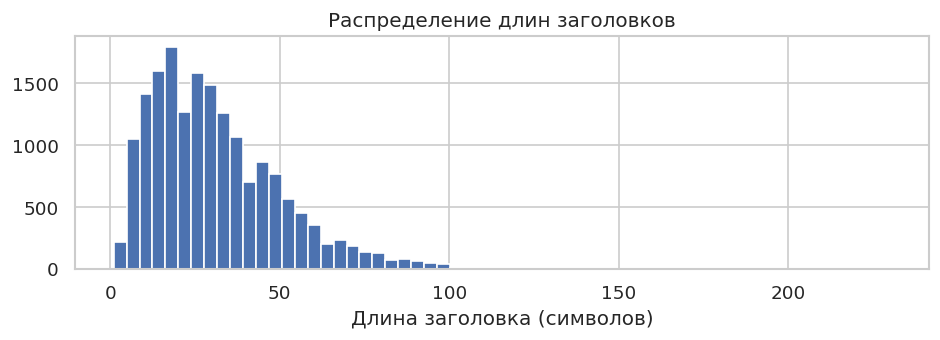

In [11]:
# Длина заголовков
df['title_len'] = df['title'].fillna('').str.len()

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df['title_len'], bins=60, edgecolor='white')
ax.set_xlabel('Длина заголовка (символов)')
ax.set_title('Распределение длин заголовков')
plt.tight_layout()
plt.show()

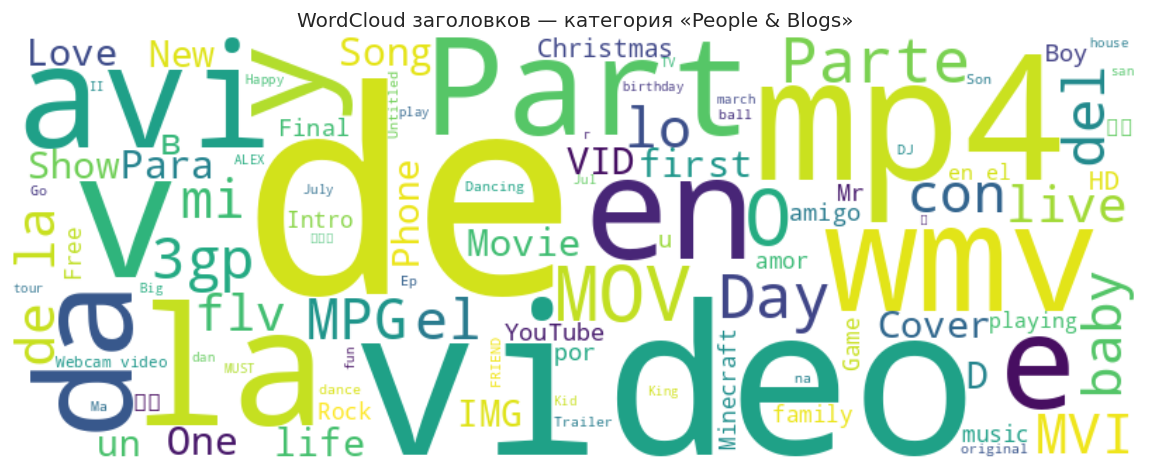

In [12]:
# Облако слов из заголовков (топ категория по количеству — берём первые 2000 строк)
top_cat = df['category'].value_counts().index[0]
titles_text = ' '.join(df.loc[df['category'] == top_cat, 'title'].fillna('').head(2000))

wc = WordCloud(width=800, height=300, background_color='white', max_words=100).generate(titles_text)
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title(f'WordCloud заголовков — категория «{top_cat}»')
plt.tight_layout()
plt.show()

---
## 3. Предобработка данных

In [14]:
# Заполняем пропуски в текстовых полях пустой строкой
for col in ['title', 'description', 'hashtags']:
    df[col] = df[col].fillna('')

# Числовые пропуски — медианой
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [15]:
# Объединяем текстовые поля в один признак
df['text'] = df['title'] + ' ' + df['description'] + ' ' + df['hashtags']

# Кодируем целевую переменную
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

print('Классы:', list(le.classes_))

Классы: ['Autos & Vehicles', 'Comedy', 'Education', 'Entertainment', 'Film & Animation', 'Gaming', 'Howto & Style', 'Music', 'News & Politics', 'Nonprofits & Activis', 'People & Blogs', 'Pets & Animals', 'Science & Technology', 'Shows', 'Sports', 'Travel & Events']


In [16]:
# Train / test split (80/20, стратификация по категории)
X_text = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 14071 | Test: 3518


---
## 4. Базовая модель: TF-IDF + Logistic Regression

Текстовые признаки (заголовок + описание + хэштеги) → TF-IDF → Logistic Regression.  
Это наш **baseline** — отправная точка для сравнения с более сложными моделями.

In [18]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=30_000,
        sublinear_tf=True,
        ngram_range=(1, 2),
        min_df=2,
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=5.0,
        solver='lbfgs',
        # multi_class='multinomial',
        random_state=42,
    )),
])

pipeline.fit(X_train, y_train)
print('Модель обучена.')

/home/wukker/IdeaProjects/video_classifier/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Модель обучена.


In [19]:
y_pred = pipeline.predict(X_test)

print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    digits=3
))

                      precision    recall  f1-score   support

    Autos & Vehicles      0.664     0.444     0.532       160
              Comedy      0.308     0.157     0.208       235
           Education      0.289     0.101     0.149       129
       Entertainment      0.310     0.286     0.298       451
    Film & Animation      0.467     0.120     0.190       117
              Gaming      0.677     0.634     0.655       284
       Howto & Style      0.333     0.088     0.140        68
               Music      0.483     0.597     0.534       593
     News & Politics      0.387     0.189     0.254       127
Nonprofits & Activis      1.000     0.022     0.043        45
      People & Blogs      0.349     0.662     0.457       789
      Pets & Animals      0.567     0.179     0.272        95
Science & Technology      0.333     0.035     0.063        57
               Shows      0.000     0.000     0.000         4
              Sports      0.444     0.293     0.353       246
     Tr

/home/wukker/IdeaProjects/video_classifier/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wukker/IdeaProjects/video_classifier/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wukker/IdeaProjects/video_classifier/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


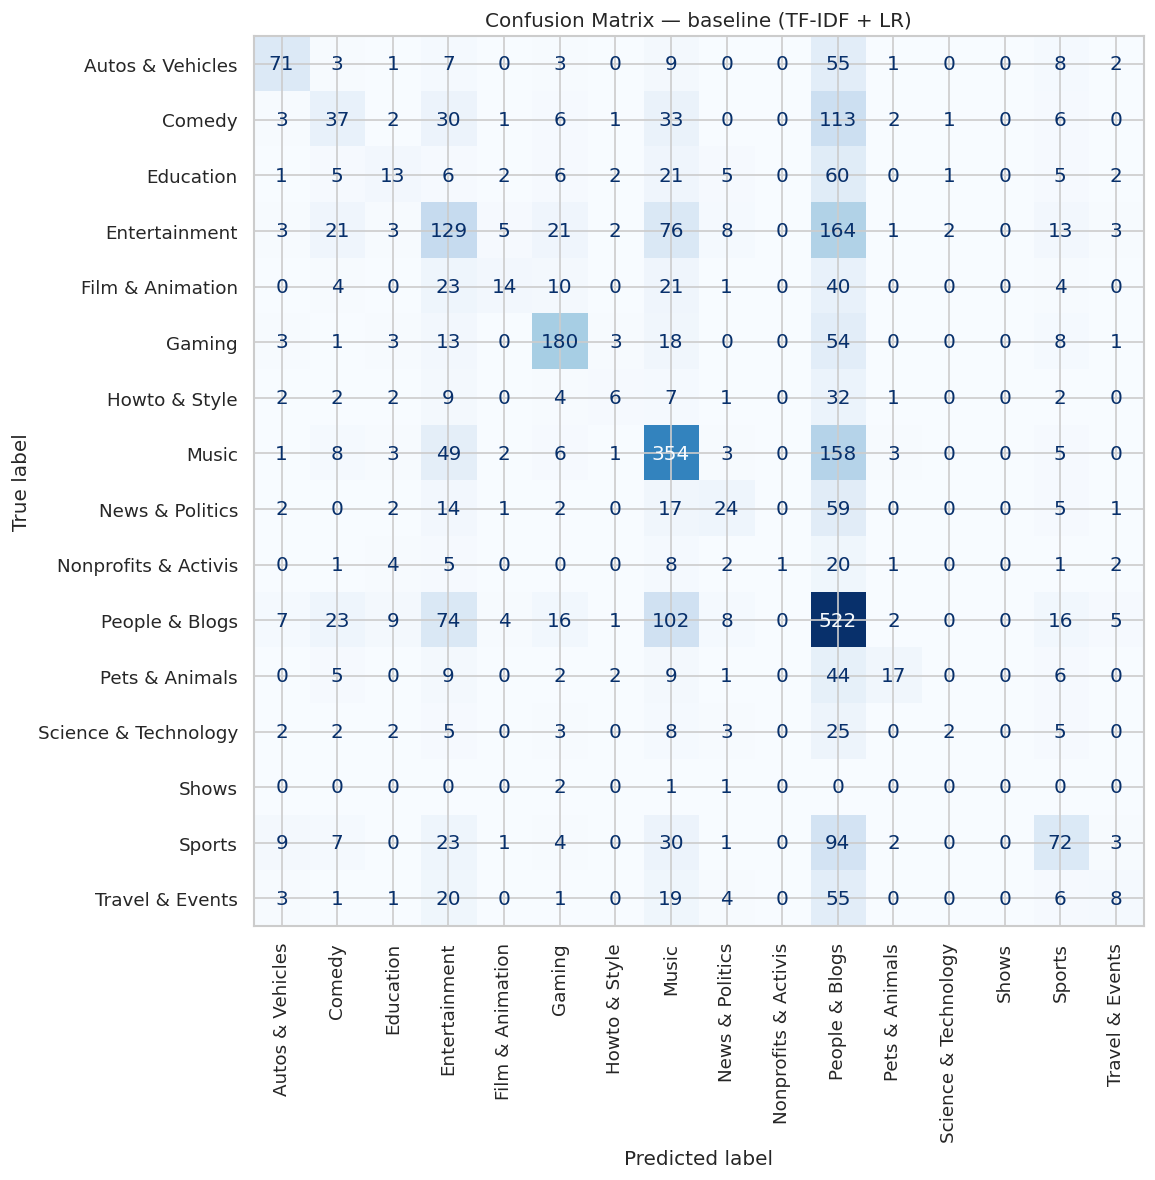

In [20]:
# Матрица ошибок
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    xticks_rotation='vertical',
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix — baseline (TF-IDF + LR)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_23182/455262126.py:25: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23182/455262126.py:25: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23182/455262126.py:25: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23182/455262126.py:25: UserWarning: Glyph 32862 (\N{CJK UNIFIED IDEOGRAPH-805E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23182/455262126.py:25: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23182/455262126.py:25: UserWarning: Glyph 3608 (\N{THAI CHARACTER THO THONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23182/455262126.py:25: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) mis

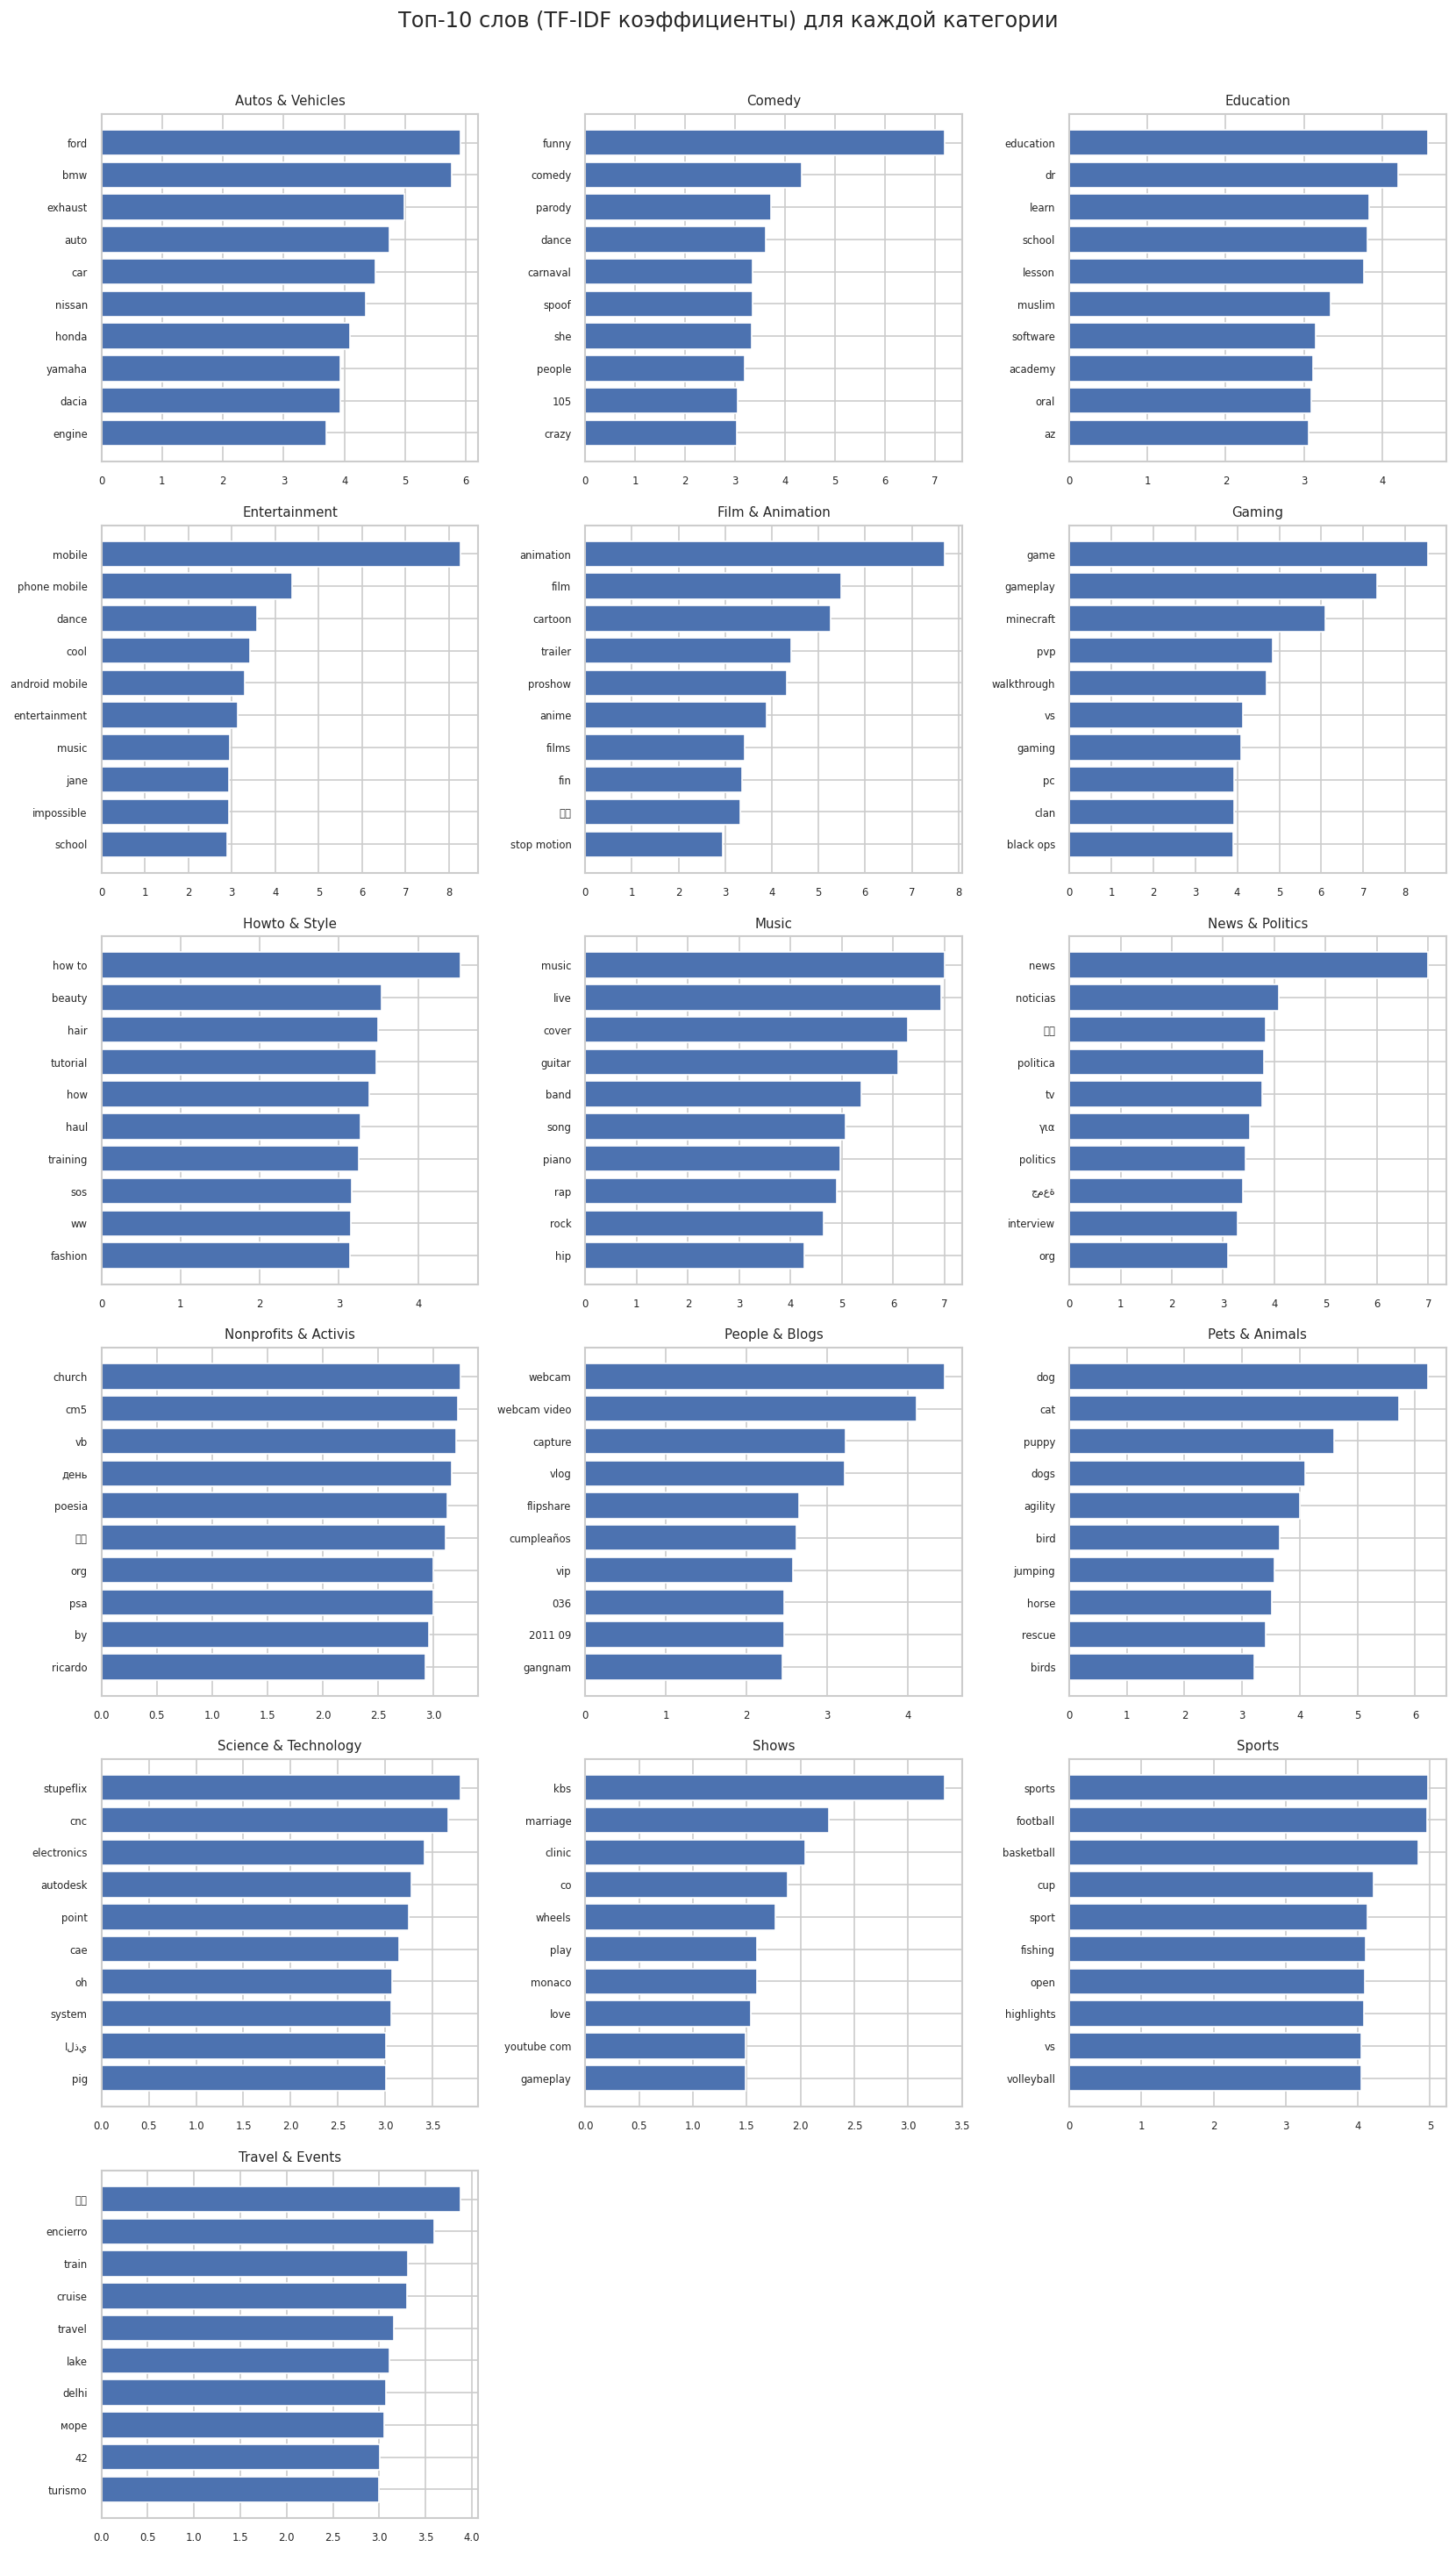

In [21]:
# Топ-20 самых влиятельных слов для каждого класса
tfidf = pipeline.named_steps['tfidf']
clf = pipeline.named_steps['clf']
feature_names = tfidf.get_feature_names_out()

top_n = 10
fig, axes = plt.subplots(
    nrows=(len(le.classes_) + 2) // 3, ncols=3,
    figsize=(14, len(le.classes_) * 1.5)
)
axes = axes.flatten()

for i, cls_name in enumerate(le.classes_):
    coef = clf.coef_[i]
    top_idx = np.argsort(coef)[-top_n:][::-1]
    axes[i].barh(feature_names[top_idx][::-1], coef[top_idx][::-1])
    axes[i].set_title(cls_name, fontsize=9)
    axes[i].tick_params(labelsize=7)

# Скрываем лишние subplot-ы
for j in range(len(le.classes_), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Топ-10 слов (TF-IDF коэффициенты) для каждой категории', y=1.01)
plt.tight_layout()
plt.show()

---
## Итоги и следующие шаги

### Что сделано:
- Загружены и изучены данные (17 624 видео, N категорий).
- Проведён разведочный анализ: распределение классов, длительность, разрешения, корреляции, word clouds.
- Выполнена базовая предобработка: удаление дублей, заполнение пропусков, объединение текстовых полей.
- Обучен baseline: **TF-IDF (1-2 graммы) + Logistic Regression**.

### Следующие шаги:
1. **Числовые признаки** — добавить duration, bitrate, resolution, FPS к тексту (FeatureUnion / ColumnTransformer).
2. **Балансировка классов** — SMOTE или `class_weight='balanced'` для редких категорий.
3. **Более сложные модели** — Random Forest, Gradient Boosting (LightGBM), SVM.
4. **Нейросетевые эмбеддинги** — sentence-transformers (multilingual-MiniLM) для многоязычных текстов.
5. **Кросс-валидация** — stratified K-Fold для надёжной оценки метрик.